In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.interpolate import make_interp_spline

df = pd.read_csv("rhfs.csv")
# count properties per owner

df.dropna(inplace=True)
rents = df[['NUMUNITS_R']].copy()
rents.rename(columns={'NUMUNITS_R': 'num_units'}, inplace=True)

In [2]:
np.random.seed(42)

scenarios = {
    "low": 10,      # 10 customers/month
    "medium": 25,   # 25 customers/month
    "high": 50      # 50 customers/month
}


months = 12  # simulate 1 year

In [3]:
def simulate_growth(rents, growth_rate, months=12):
    """Simulate customer growth and units owned over time."""
    monthly_data = []

    cumulative_customers = 0
    cumulative_units = 0

    for month in range(1, months + 1):
        new_customers = growth_rate
        cumulative_customers += new_customers

        # Sample num_units for each new customer
        sampled_units = rents['num_units'].sample(new_customers, replace=True).values
        total_new_units = sampled_units.sum()

        cumulative_units += total_new_units

        monthly_data.append({
            "Month": month,
            "New_Customers": new_customers,
            "New_Units": total_new_units,
            "Cumulative_Customers": cumulative_customers,
            "Cumulative_Units": cumulative_units
        })

    return pd.DataFrame(monthly_data)

In [4]:
results = {}

for scenario, growth_rate in scenarios.items():
    results[scenario] = simulate_growth(rents, growth_rate)

In [5]:
for scenario, df_result in results.items():
    df_result.to_csv(f"growth_scenario_{scenario}.csv", index=False)

In [6]:
# 1. Set random seed
np.random.seed(42)

# 2. Build a synthetic distribution
# Majority small (1-20 units), small chance medium (21-50), rare large (51-250)

small_landlords = np.random.randint(1, 21, size=900)     # 90% small landlords
medium_landlords = np.random.randint(21, 51, size=80)    # 8% medium landlords
large_landlords = np.random.randint(51, 251, size=20)    # 2% large landlords

# Combine all
synthetic_units = np.concatenate([small_landlords, medium_landlords, large_landlords])

# 3. Build synthetic rents dataframe
synthetic_rents = pd.DataFrame({"num_units": synthetic_units})

# Check the stats
print(synthetic_rents.describe())

         num_units
count  1000.000000
mean     14.992000
std      22.557632
min       1.000000
25%       5.000000
50%      11.000000
75%      17.000000
max     240.000000


In [7]:
results = {}

for scenario, growth_rate in scenarios.items():
    results[scenario] = simulate_growth(synthetic_rents, growth_rate)

In [8]:
for scenario, df_result in results.items():
    df_result.to_csv(f"growth_scenario_{scenario}_updated.csv", index=False)

C:\Users\Ben\AppData\Local\Temp\ipykernel_12840\3989206205.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


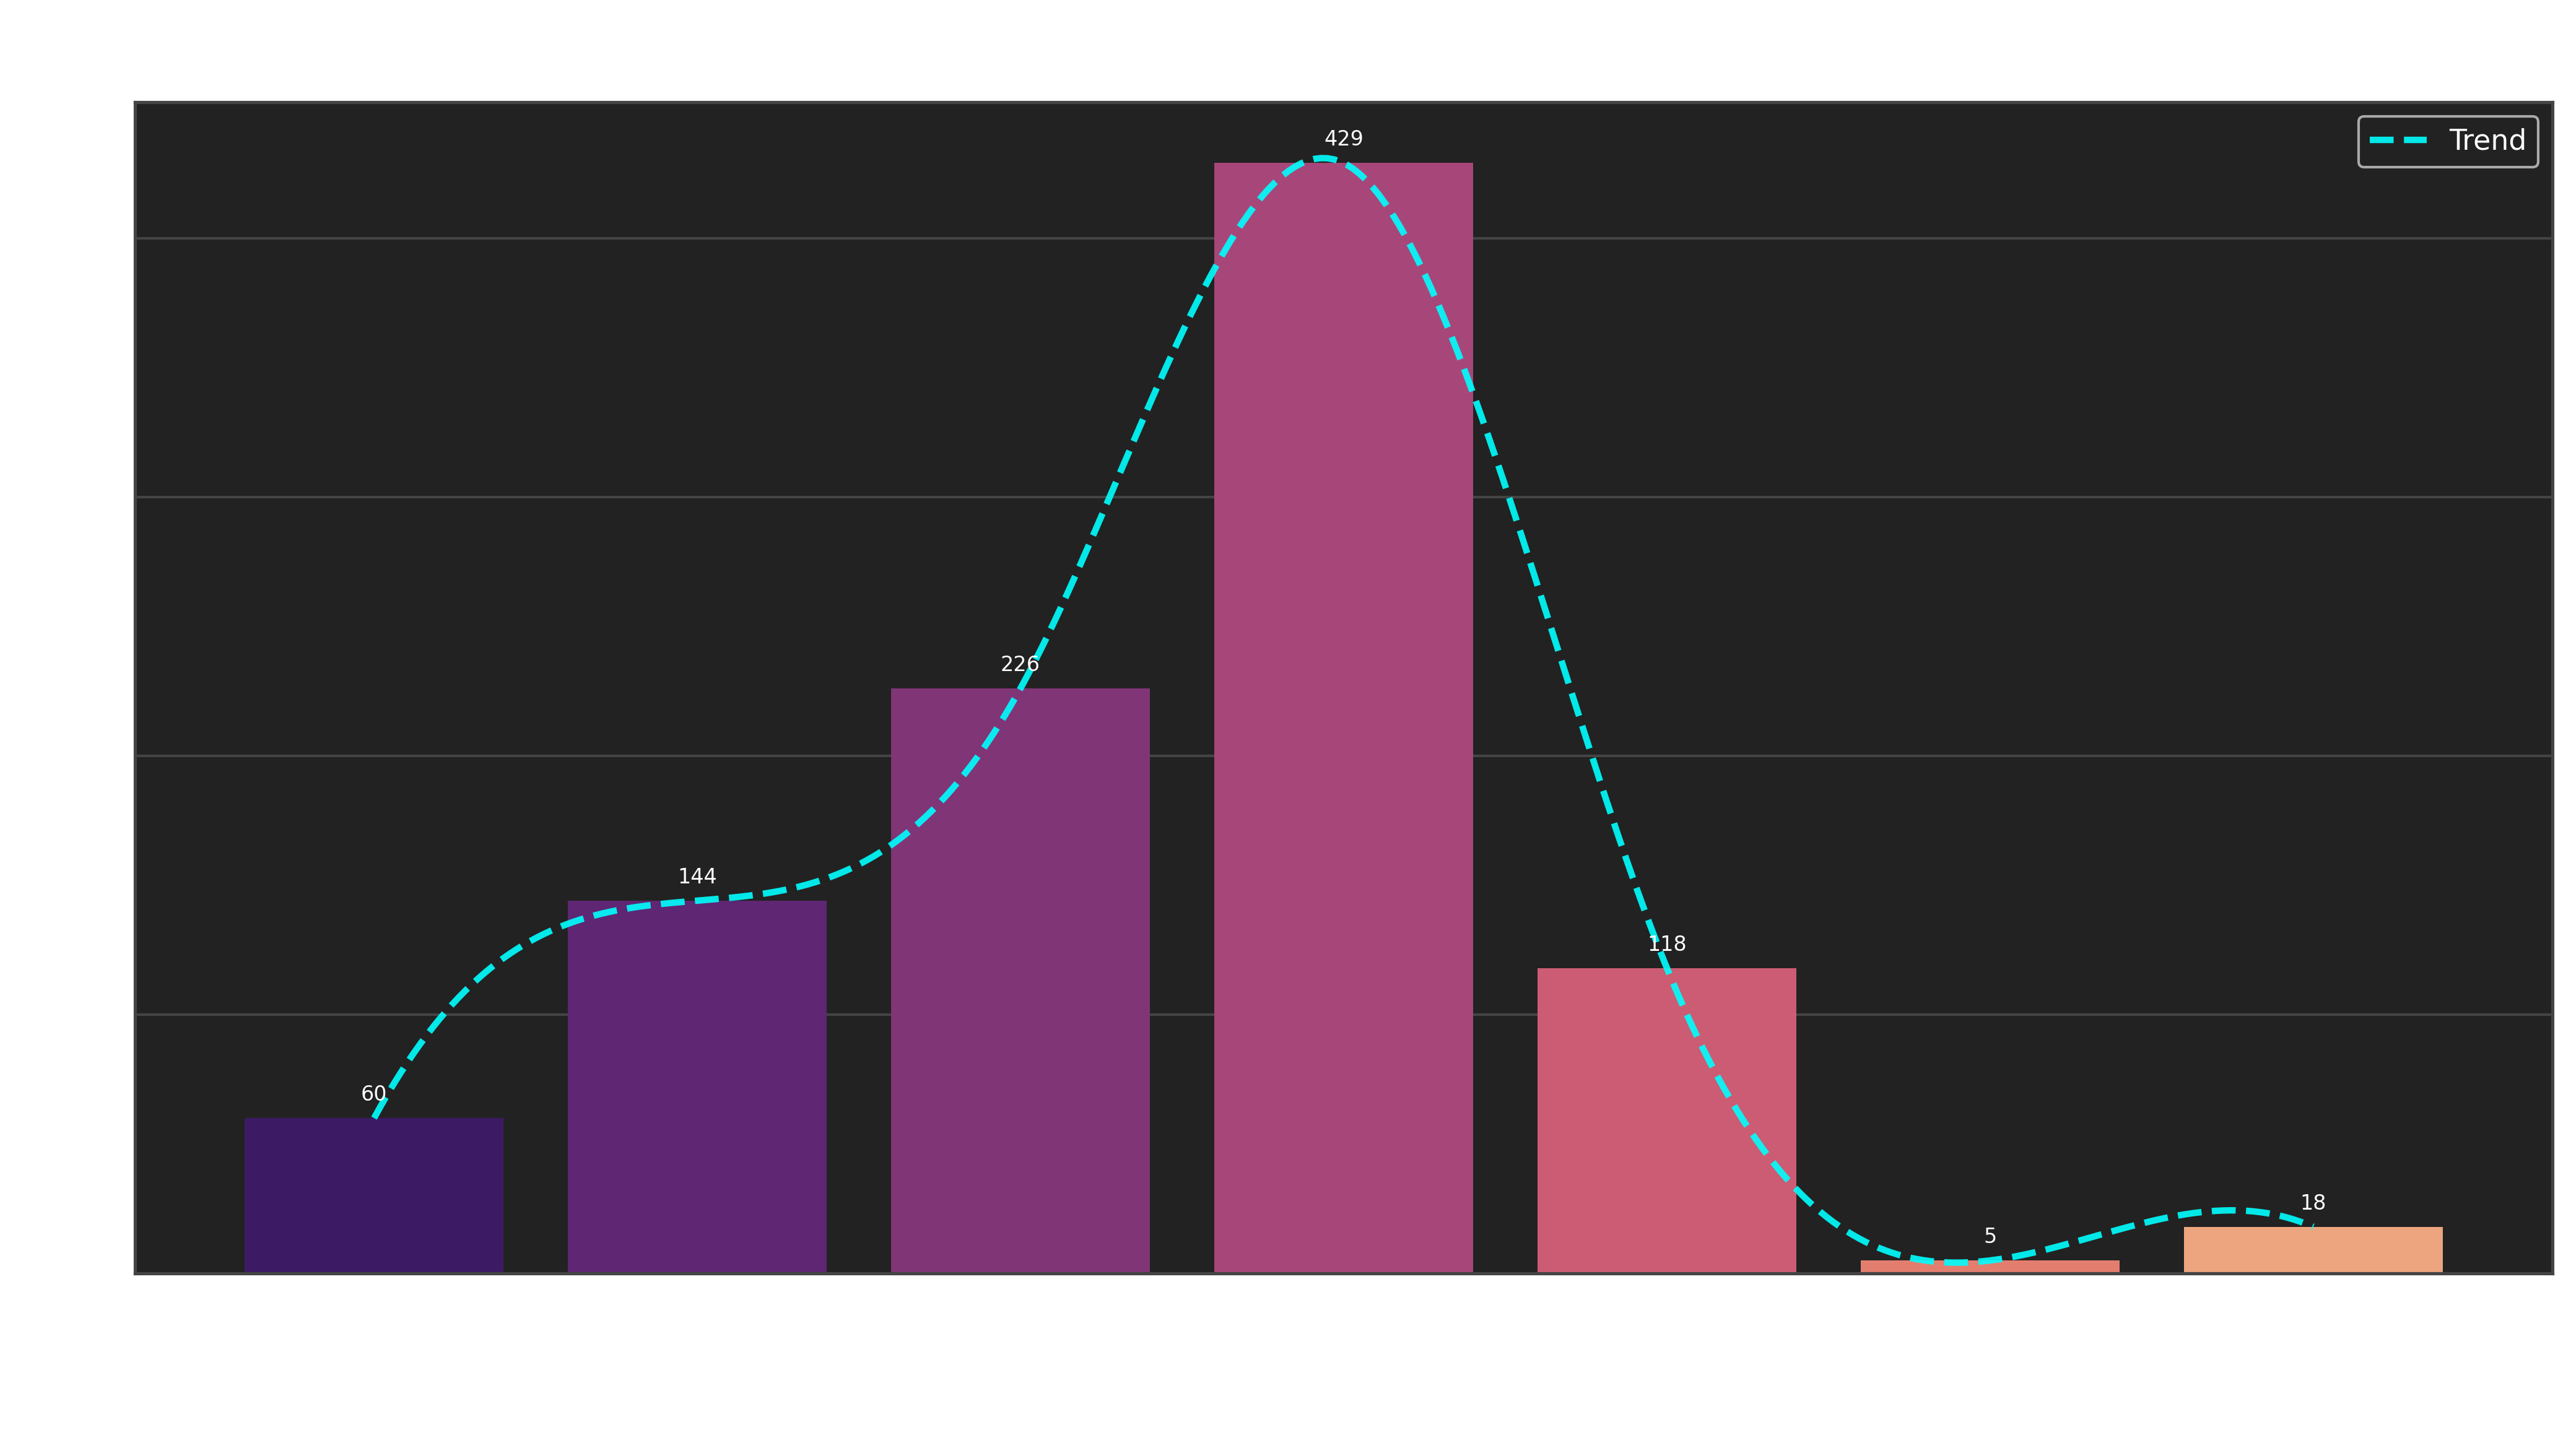

In [9]:
# --- Binning ---
bins = [1, 2, 5, 10, 20, 50, 100, 250]
labels = ["1 unit", "2–4", "5–9", "10–19", "20–49", "50–99", "100–250"]

synthetic_rents['unit_bin'] = pd.cut(
    synthetic_rents['num_units'],
    bins=bins,
    labels=labels,
    right=False,
    include_lowest=True
)

bin_counts = synthetic_rents['unit_bin'].value_counts().reindex(labels)

# --- Plot setup ---
plt.figure(figsize=(14, 8), dpi=300)

sns.set_theme(style="darkgrid", rc={
    "axes.facecolor": "#222222",
    "figure.facecolor": "#222222",
    "axes.edgecolor": "#444444",
    "grid.color": "#444444",
    "axes.labelcolor": "white",
    "xtick.color": "white",
    "ytick.color": "white",
    "text.color": "white",
    "font.family": "DejaVu Sans"
})

x_labels = bin_counts.index
x_numeric = np.arange(len(x_labels))
y_values = bin_counts.values

# --- Magma color palette ---
cmap = plt.get_cmap("magma")
colors = list(cmap(np.linspace(0.2, 0.8, len(x_labels))))

# --- Bars ---
ax = sns.barplot(
    x=x_numeric,
    y=y_values,
    palette=colors,
    edgecolor="none",
    legend=False
)

# Bar labels
for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f"{int(height):,}",
        (p.get_x() + p.get_width() / 2, height),
        ha='center',
        va='bottom',
        fontsize=8,
        color='white',
        xytext=(0, 5),
        textcoords='offset points'
    )

# --- Smooth trend line ---
x_smooth = np.linspace(x_numeric.min(), x_numeric.max(), 300)
spline = make_interp_spline(x_numeric, y_values, k=3)
y_smooth = spline(x_smooth)

plt.plot(x_smooth, y_smooth, color="cyan", linewidth=2.5, linestyle="--", alpha=0.9, label="Trend")

# --- Final labels ---
plt.xlabel("Units Owned", fontsize=13, color='white')
plt.ylabel("Number of Landlords", fontsize=13, color='white')
plt.title("Synthetic Early Customer Units Distribution", fontsize=16, weight='bold', color='white', pad=20)

plt.xticks(
    ticks=x_numeric,
    labels=x_labels,
    rotation=45,
    ha='right',
    fontsize=10,
    color='white'
)
plt.yticks(fontsize=10, color='white')

plt.legend()
plt.tight_layout()
plt.show()